<a href="https://colab.research.google.com/github/zawiskrz/data-lab-python311/blob/main/GUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
https://stat.gov.pl/download/gfx/portalinformacyjny/pl/defaultaktualnosci/5486/9/17/1/budzety_gospodarstw_domowych_w_2021.zip

In [ ]:
from urllib.request import urlretrieve
urlretrieve(url="https://stat.gov.pl/download/gfx/portalinformacyjny/pl/defaultaktualnosci/5486/9/21/1/budzety_gospodarstw_domowych_w_2022_r._tablice_1-74.zip",
            filename="/content/drive/MyDrive/Andrzej/studia/praca_dyplomowa/dane/2022.zip")

('/content/drive/MyDrive/Andrzej/studia/praca_dyplomowa/dane/2022.zip',
 <http.client.HTTPMessage at 0x7de9c8c2dc60>)

In [ ]:
# @title Example form fields
# @markdown Forms support many types of fields.

no_type_checking = ''  # @param
string_type = 'example'  # @param {type: "string"}
slider_value = 117  # @param {type: "slider", min: 100, max: 200}
number = 102  # @param {type: "number"}
date = '2010-11-05'  # @param {type: "date"}
pick_me = "monday"  # @param ['monday', 'tuesday', 'wednesday', 'thursday']
select_or_input = "apples" # @param ["apples", "bananas", "oranges"] {allow-input: true}
# @markdown ---

In [ ]:
from vega_datasets import data
stocks = data.stocks()

import altair as alt
alt.Chart(stocks).mark_line().encode(
  x='date:T',
  y='price',
  color='symbol'
).interactive(bind_y=False)

alt.Chart(...)

# Zagadnienie

1.   Porównanie sytuacji finansowej grup społeczno ekonomicznych gospodarstw domowych w Polsce w okresie pandemii Covid 19. (Wykorzystanie metody [TOPSIS](https://repozytorium.uwb.edu.pl/jspui/bitstream/11320/7542/1/Optimum_4_2018_D_Kacprzak_Przedzialowa_metoda_TOPSIS.pdf) )
2.   Poziom i struktura wydatków miejskich i wiejskich gospodarstw wiejskich i miejskich w Polsce w okresie pandemii COVID 19





# Definicje funkcji

In [ ]:
def plot_dfs(df,title=None, kolumny=None,add_hline=False,rok='2020'):
    '''
    df: dataframe with missing data
    kolumny: lista posortowanych kolumn
    '''

    columns = df.columns.tolist() if kolumny is None else kolumny
    subplots_size = len(columns)

    subplots_size = df.shape[1]

    fig, ax = plt.subplots(subplots_size, 1, sharex=True, figsize=(10, 16))
    plt.subplots_adjust(hspace=0.25)
    fig.suptitle = title

    for i, colname in enumerate(columns):
        df[colname].plot(ax=ax[i])
        ax[i].set_title(colname)
        if add_hline == True:
          ax[i].axhline(y=0, color='green', linewidth=1, alpha=0.5)
          y_value = df[colname].loc[df.index == rok]
          x_value = [x[0] for x in enumerate(df.index) if x[1] == rok]
          ax[i].plot(x_value, y_value, marker='o', markerfacecolor='red', markersize=5)
    plt.show()



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

def istotnosc_cech(df,X,Y,treshold=0.07):
  '''
    df: dataframe przed skalowaniem
    X: cechy
    Y: target
  '''
  model = LogisticRegression()
  model.fit(X,Y)
  # Utwórz obiekt SelectFromModel
  selector = SelectFromModel(model, threshold=treshold)

  # Dopasuj model do danych
  selector.fit(X, Y)

  # Pobierz wybrane cechy
  selected_features = selector.get_support()
  nazwy_cech = [x[1] for x in df.columns[selected_features]]

  # Pobierz współczynniki dla wybranych cech
  wspolczynniki = list(model.coef_[0][selected_features])

  cechy_df = pd.DataFrame(zip(nazwy_cech,wspolczynniki),columns=['Cechy','wspolczynniki'])
  cechy_df['wspolczynniki_abs'] = cechy_df['wspolczynniki'].abs()
  cechy_df = cechy_df.sort_values('wspolczynniki_abs',ascending=True).drop('wspolczynniki_abs',axis=1).set_index('Cechy')
  return(cechy_df)

In [ ]:
def wybierz_znak_cech(df1,df2,czy_dodatni=True,ilosc_cech=5):
  '''
  df1: dataframe z cechami
  df2: dataframe z istotnymi cechami
  czy_dodatni: Znak dodatni oznaczy istotność dodatnią
  ilosc_cech: Ilość najistotniejszych cech dla danego znaku
  '''
  kolumny=[]
  if(czy_dodatni==True):
    kolumny = [x for x in df2.loc[df2['wspolczynniki']>0].sort_values('wspolczynniki',ascending = False).iloc[:ilosc_cech+1,:].index]
  else:
    kolumny = [x for x in df2.loc[df2['wspolczynniki']< 0].sort_values('wspolczynniki',ascending = True).iloc[:ilosc_cech+1,:].index]
  cechy = [(x,y[0]) for x in df1.columns for y in enumerate(kolumny) if x[1] in y[1]]
  cechy = [x[0] for x in sorted(cechy,key=lambda x:x[1])]
  return(cechy)

In [ ]:
def plot_importance(df):
  '''
  df: dataframe z cechami
  '''
  plt.barh(df.index,df['wspolczynniki'],color = ['g' if value > 0 else 'r' for value in df['wspolczynniki']])
  plt.xlabel('Cechy')
  plt.ylabel('wspolczynniki')
  plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
def standaryzacja_cech(df):
  '''
  df: dataframe z cechami do standaryzacji
  '''
  scaler = StandardScaler()
  scaler.fit(df)
  wynik = scaler.transform(df)
  return(wynik)

In [ ]:
import pandas as pd
dane = pd.read_excel("/content/drive/MyDrive/Andrzej/studia/GUS/warunkiMaterialne.xlsx",sheet_name="Warunki_materialne")
dane

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Andrzej/studia/GUS/warunkiMaterialne.xlsx'

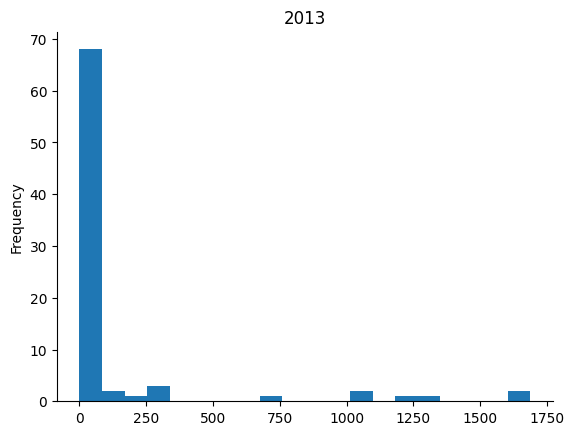

In [ ]:
# @title 2013

from matplotlib import pyplot as plt
dane['2013'].plot(kind='hist', bins=20, title='2013')
plt.gca().spines[['top', 'right',]].set_visible(False)


# Import danych Warunki Materialne Gospodarstw Domowych

In [ ]:
dane = pd.read_excel("/content/drive/MyDrive/Andrzej/studia/GUS/warunkiMaterialne.xlsx",sheet_name="Warunki_materialne") \
        .drop('Unnamed: 3',axis=1)
dane = dane \
       .assign(
            grupa=dane['Wyszczególnienie'].str.split(';', n=1).str[0],
            miara=dane['Wyszczególnienie'].str.split(';', n=1).str[1],
        ) \
        .drop('Wyszczególnienie',axis=1)

# Zdefiniuj słownik mapujący nazwy grup na krótsze nazwy
slownik_grupy = {
    'Przeciętne miesięczne przychody netto na 1 osobę w gospodarstwach domowych': "przychody",
    'Przeciętne miesięczne rozchody netto na 1 osobę w gospodarstwach domowych': 'rozchody',
    'Przeciętne miesięczne spożycie wybranych artykułów żywnościowych na 1 osobę w gospodarstwach domowych':'spożycie',
}

# Zmapuj nazwy grup
dane['grupa'] = dane['grupa'].map(slownik_grupy)
dane = dane \
        .set_index(['grupa','miara']) \
        .stack() \
        .unstack(['grupa','miara']) \
        .apply(pd.to_numeric, errors='coerce')


# Zastąpienie brakujących wartości

In [ ]:
# wybierz kolumny z wartością null
kolumny_isnull = dane.isnull().sum(axis=0)[dane.isnull().sum(axis=0) > 0].index

In [ ]:
dane[kolumny_isnull]

grupa                              przychody  \
miara  Zasiłki dla bezrobotnych krajowe [zł]   
2010                                    4.20   
2011                                    3.67   
2012                                    4.31   
2013                                    4.57   
2014                                    3.46   
2015                                    2.92   
2016                                    2.52   
2017                                    2.33   
2018                                    1.77   
2019                                    1.81   
2020                                     NaN   
2021                                     NaN   

grupa                          spożycie                           \
miara  Pozostałe wyroby piekarskie [kg]  Płatki śniadaniowe [kg]   
2010                                NaN                      NaN   
2011                                NaN                      NaN   
2012                                NaN                      NaN   
2013                               0.73                     0.14   
2014                               0.76                     0.13   
2015                               0.78                     0.13   
2016                               0.87                     0.14   
2017                               0.93                     0.15   
2018                               0.94                     0.15   
2019                               0.98                     0.16   
2020                               0.99                     0.18   
2021                               1.05                     0.16   

grupa                                                       \
miara  Ryby i owoce morza suszone, wędzone lub solone [kg]   
2010                                                 NaN     
2011                                                 NaN     
2012                                                 NaN     
2013                                                0.10     
2014                                                0.10     
2015                                                0.10     
2016                                                0.11     
2017                                                0.10     
2018                                                0.10     
2019                                                0.10     
2020                                                0.10     
2021                                                0.10     

grupa                       \
miara  Owoce jagodowe [kg]   
2010                   NaN   
2011                   NaN   
2012                   NaN   
2013                  0.43   
2014                  0.47   
2015                  0.47   
2016                  0.43   
2017                  0.41   
2018                  0.42   
2019                  0.40   
2020                  0.42   
2021                  0.43   

grupa                                                           \
miara  Owoce suszone, mrożone, orzechy, przetwory owocowe [kg]   
2010                                                 NaN         
2011                                                 NaN         
2012                                                 NaN         
2013                                                0.15         
2014                                                0.15         
2015                                                0.15         
2016                                                0.16         
2017                                                0.18         
2018                                                0.19         
2019                                                0.21         
2020                                                0.23         
2021                                                0.25         

grupa                                                                    \
miara  Warzywa świeże lub chłodzone [kg]  Warzywa i grzyby mrożone [kg]   
2010     

<Axes: >

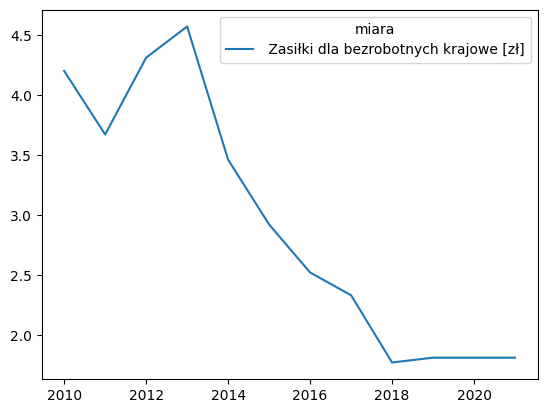

In [ ]:
# wypełnienie brakujących wartości metodą w przód
dane[kolumny_isnull[0]] = dane[kolumny_isnull[0]].fillna(method='ffill')
dane[kolumny_isnull]['przychody'].fillna(method='ffill').plot()

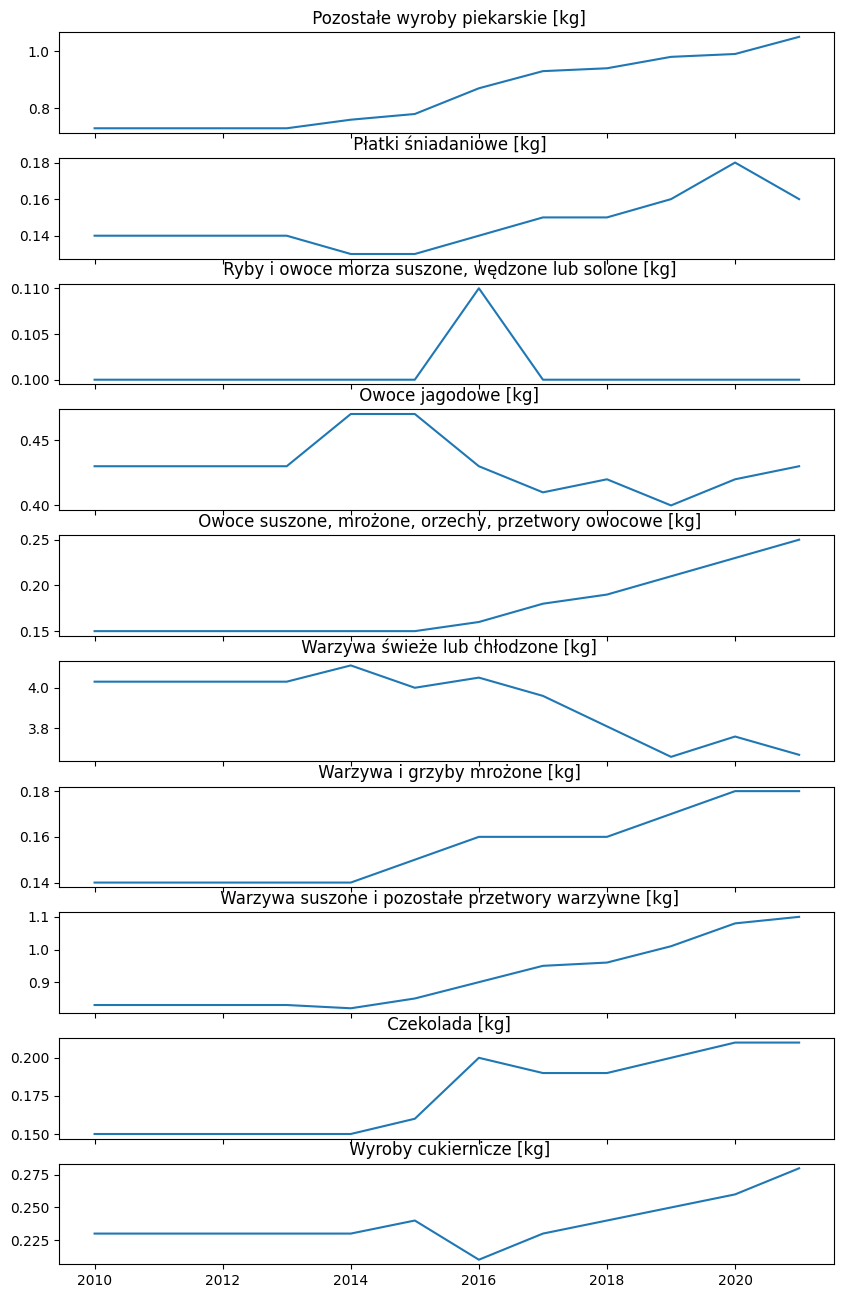

In [ ]:
# wypełnienie brakujących wartośći metodą wstecz
dane[kolumny_isnull[1:]] = dane[kolumny_isnull[1:]].fillna(method='bfill')
plot_dfs(dane[kolumny_isnull]['spożycie'].fillna(method='bfill'))

# Wyliczenie targetu

In [ ]:
#Dodaj kolumnę "covid"
czy_covid = pd.Series(['1' if x == '2020' else '0' for x in dane.index])

# Trenowanie modelu i wybór cech dla danych bez trendu

  ## Standaryzacja cech

In [ ]:
dane_bez_trendu = dane.diff().dropna()
dane_bez_trendu_scaled = standaryzacja_cech(dane_bez_trendu)

  ## Wybór istotnych cech

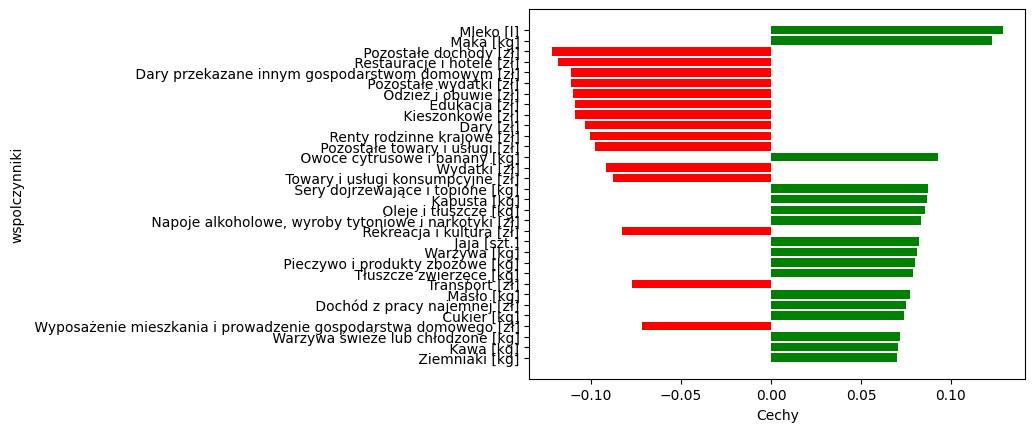

In [ ]:
istotnosc_df2 = istotnosc_cech(df=dane_bez_trendu,X=dane_bez_trendu_scaled,Y= czy_covid[1:])
plot_importance(df = istotnosc_df2)

  ## Wykres dla cech istotnych

  ### Cechy dodatnie

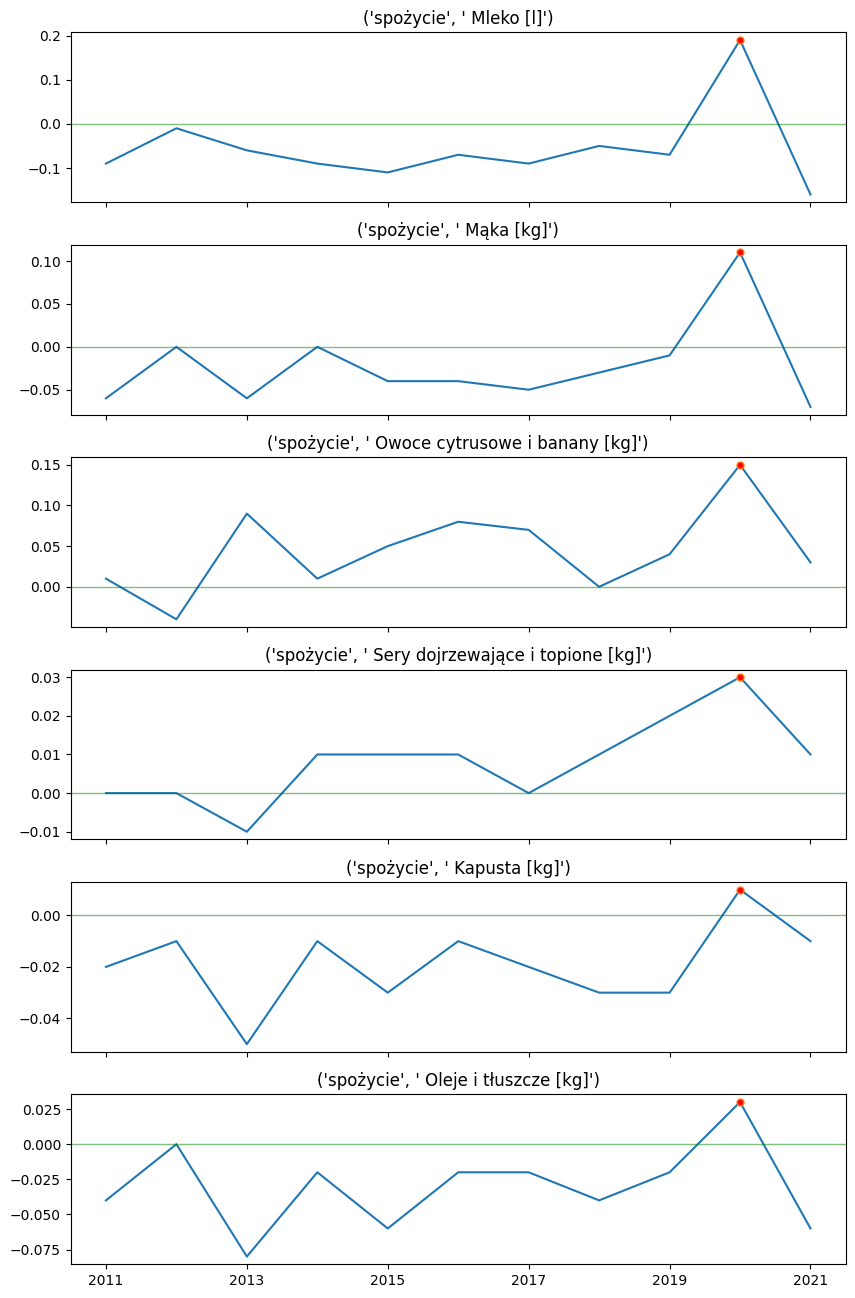

In [ ]:
grupy_kolumny_wplyw_dodatni2 = wybierz_znak_cech(df1=dane_bez_trendu,df2=istotnosc_df2,czy_dodatni=True,ilosc_cech=5)
plot_dfs(dane_bez_trendu[grupy_kolumny_wplyw_dodatni2],add_hline=True)

  ### Cechy ujemne

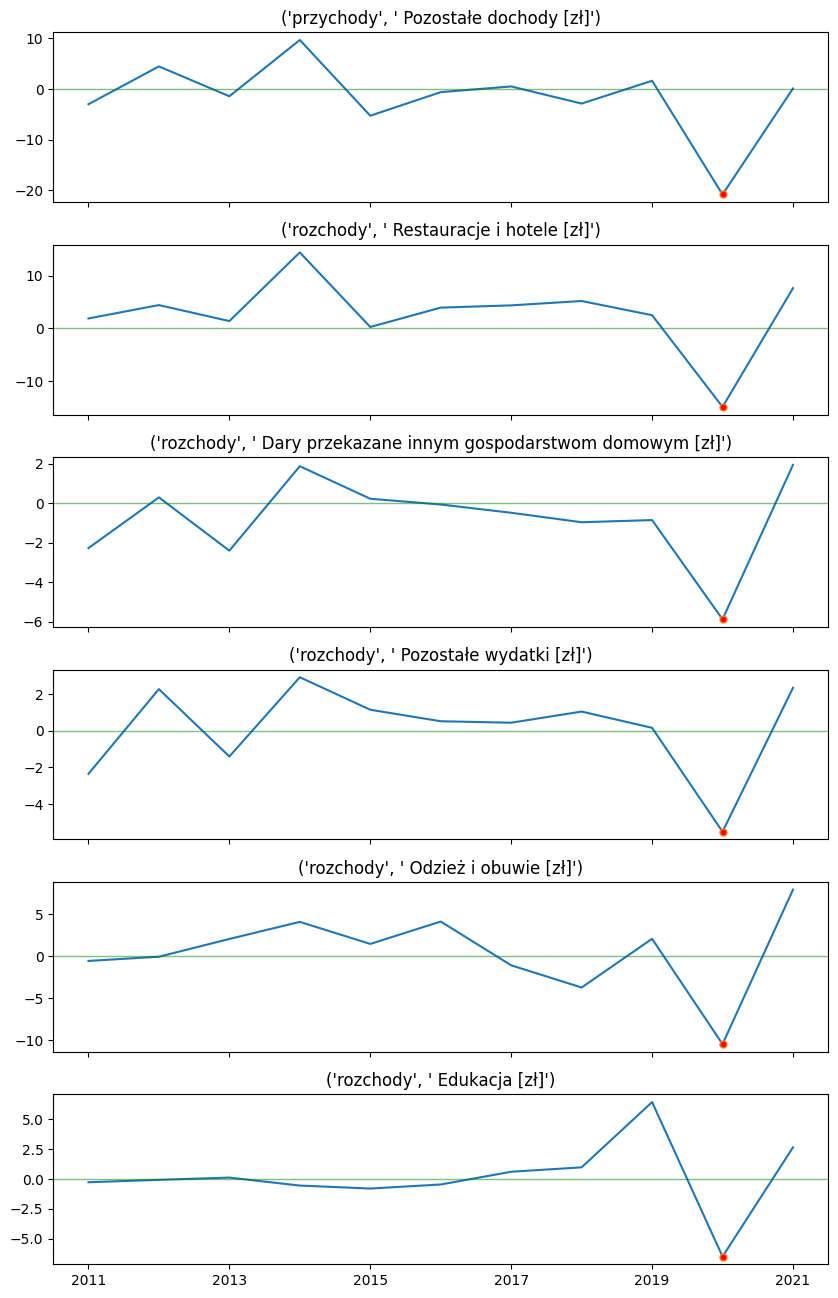

In [ ]:
grupy_kolumny_wplyw_ujemny2 = wybierz_znak_cech(df1=dane_bez_trendu,df2=istotnosc_df2,czy_dodatni=False,ilosc_cech=5)
plot_dfs(dane_bez_trendu[grupy_kolumny_wplyw_ujemny2],add_hline=True)

  ##  Przyrost względny jednopodstawowy względem 2020 roku i przyrost względny łańcuchowy

In [ ]:
przyrost_jednopodstawowy = (dane - dane.loc['2020',])/dane.loc['2020',]
przyrost_lancuchowy = dane.diff().dropna()/dane.iloc[1:]